In [ ]:
import sys, hashlib, json
from pathlib import Path

def _repo_root() -> Path:
    p = Path.cwd().resolve()
    for d in (p, *p.parents):
        if (d / "config.py").exists() and (d / "src").is_dir():
            return d
    raise RuntimeError(f"repo root not found above {p}")

ROOT = _repo_root()
sys.path.insert(0, str(ROOT))

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from src import db
from src.backtest.runner import SEPABacktestRunner
from src.backtest.universe_scorer import UniverseScorer
from src.backtest.score_lookup import prototype_scores_to_contract

# --- canonical config (ONE name per thing) ---
DB_PATH   = ROOT / "data" / "market_data.duckdb"        # Path; str() at call sites
CASH      = 25_000
BINARY    = str(ROOT / "models" / "m01_binary" / "v1" / "model.json")
PROTO_VER = "m01_prototype_2003_2026_20260514_233125"
CACHE_DIR = ROOT / "data" / "backtest_cache"; CACHE_DIR.mkdir(parents=True, exist_ok=True)

assert DB_PATH.exists(), f"DB missing at {DB_PATH}"
print(f"DB: {DB_PATH.name} ({DB_PATH.stat().st_size/1e9:.1f} GB) · cache: {CACHE_DIR}")

DB: market_data.duckdb (84.1 GB) · cache: C:\Users\Hang\PycharmProjects\quantamental\data\backtest_cache


: 

In [2]:
def load_scores(signal: str):
    """signal in {'binary','proto'} -> (scores_df, (start,end)). binary is honest
    multi-regime (2021+); proto is the bull-only prod path (2025-10+)."""
    if signal == "binary":
        s = UniverseScorer(m01_path=BINARY, calibration_path=None).score_from_t3(
            "2021-01-01", "2026-05-22", db_path=str(DB_PATH))
        return s, ("2021-01-01", "2026-05-22")
    if signal == "proto":
        con = db.connect(str(DB_PATH), read_only=True)
        raw = con.execute("""SELECT prediction_date AS date, ticker,
            prob_class_3 AS prob_elite FROM daily_predictions
            WHERE model_version_id=? AND prediction_date BETWEEN ? AND ?""",
            [PROTO_VER, "2025-10-06", "2026-05-22"]).df()
        con.close()
        return prototype_scores_to_contract(raw), ("2025-10-06", "2026-05-22")
    raise ValueError(signal)

# load once, reuse across all experiments (⏳ binary ~2min)
SIGNAL = "binary"
scores, WINDOW = load_scores(SIGNAL)
print(f"[{SIGNAL}] {len(scores):,} rows · {scores['date'].nunique()} days · "
      f"prob_elite max={scores['prob_elite'].max():.2f}")

No calibration table at None


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

[binary] 3,093,803 rows · 1353 days · prob_elite max=0.94


In [3]:
# A strategy is (Entry, Stop, TP, Selection). Each component -> engine kwargs.
# The fingerprint NAME is built from the chosen components + their grid suffix,
# and is the cache key. See docs/.../strategy_exploration_summary.md for the index table.

def build_strategy(entry="E1", stop="X1.sl10", tp="X3.sma50", selection="S0.top",
                   entry_grid=None, **extra):
    """Return (fingerprint_name, strategy_kwargs). Components are strings like
    'E2.d3', 'X1.sl15', 'X4.atr2', 'X3.sma20'. Unknown suffixes pass through as-is."""
    kw = dict(entry_mode="top_n", entry_top_n=5, rank_by="prob_elite",
              min_prob_elite=0.0, min_score=0,
              regime_max_pos={0:0,1:5,2:5,3:5,4:5}, sizing_mode="equal_weight",
              sma_exit_independent=True, min_hold_days=3)

    # --- Entry ---
    e_idx, _, e_suf = entry.partition(".")
    if e_idx == "E1":
        kw["entry_delay_days"] = 0
    elif e_idx == "E2":
        kw["entry_delay_days"] = int(e_suf.replace("d","")) if e_suf else 3
        g = entry_grid or dict(entry_ret_lo=-0.15, entry_ret_hi=0.30)
        kw.update(g)

    # --- Stop (SL) ---
    s_idx, _, s_suf = stop.partition(".")
    if s_idx == "X1":
        kw["max_stop_pct"] = int(s_suf.replace("sl",""))/100 if s_suf else 0.10
        kw["atr_stop_mult"] = 0.0
    elif s_idx == "X4":
        kw["atr_stop_mult"] = float(s_suf.replace("atr","")) if s_suf else 2.0

    # --- Take-profit / trend exit ---
    t_idx, _, t_suf = tp.partition(".")
    if t_idx == "X3":
        kw["sma_exit_period"] = int(t_suf.replace("sma","")) if t_suf else 50
    elif t_idx == "X2":   # score-drop rotation exit
        kw["score_drop_thresh"] = 0.08; kw["score_exit_floor"] = 0.10

    kw.update(extra)
    name = f"{entry}_{stop}_{tp}_{selection}"
    return name, kw

# selection is applied to the SCORES, not the kwargs (see Cell D rank_key).

In [4]:
def _cache_key(name, signal, window, cash, seed=None):
    raw = f"{name}|{signal}|{window[0]}_{window[1]}|{cash}|{seed}"
    h = hashlib.md5(raw.encode()).hexdigest()[:10]
    safe = name.replace("/", "-")
    return CACHE_DIR / f"{safe}__{signal}__{h}.parquet"

def run_strategy(name, kwargs, scores_df, signal, window, cash=CASH, seed=None, use_cache=True):
    """Run (or load) one strategy. Caches the TRADE HISTORY to parquet + metrics
    sidecar json. Returns (trades_df, metrics_dict). Reuse across sessions."""
    cache = _cache_key(name, signal, window, cash, seed)
    meta = cache.with_suffix(".json")
    if use_cache and cache.exists() and meta.exists():
        return pd.read_parquet(cache), json.loads(meta.read_text())

    r = SEPABacktestRunner(start_date=window[0], end_date=window[1], initial_cash=cash,
                           db_path=str(DB_PATH), model_path=None, model_version_id=None)
    r.setup(scores_df=scores_df, strategy_kwargs=kwargs)
    m = r.run()
    tr = r.get_trade_dataframe()
    tr = tr if tr is not None else pd.DataFrame()
    # persist equity too (small) for later charting without a re-run
    eq = r.get_equity_curve_dataframe()
    metrics = {k: (float(v) if isinstance(v, (int, float)) and v == v else v)
               for k, v in m.items() if not isinstance(v, (dict, list))}
    metrics["fingerprint"] = name; metrics["signal"] = signal
    metrics["window"] = list(window); metrics["cash"] = cash; metrics["seed"] = seed
    tr.to_parquet(cache, index=False)
    if eq is not None: eq.to_parquet(cache.with_name(cache.stem + "__equity.parquet"))
    meta.write_text(json.dumps(metrics, indent=2, default=str))
    return tr, metrics

def load_equity(name, signal, window, cash=CASH, seed=None):
    p = _cache_key(name, signal, window, cash, seed)
    ep = p.with_name(p.stem + "__equity.parquet")
    return pd.read_parquet(ep) if ep.exists() else None

In [5]:
# Define the strategies you want to compare purely by their fingerprint components.
STRATS = [
    build_strategy(entry="E1", stop="X1.sl10", tp="X3.sma50"),               # survivor
    build_strategy(entry="E1", stop="X1.sl15", tp="X3.sma50"),               # wider stop
    build_strategy(entry="E2.d3", stop="X1.sl10", tp="X2",                   # rotation
                   entry_grid=dict(entry_ret_lo=-0.05, entry_ret_hi=0.15)),
    build_strategy(entry="E1", stop="X4.atr2", tp="X3.sma50"),               # ATR stop
]

rows = []
for name, kw in STRATS:
    tr, m = run_strategy(name, kw, scores, SIGNAL, WINDOW)   # cached after 1st run
    rows.append(dict(fingerprint=name, trades=m.get("total_trades"),
                     ret=round(m.get("total_return",0),1), sharpe=round(m.get("sharpe_ratio") or 0,2),
                     maxDD=round(m.get("max_drawdown",0),1), win=round(m.get("win_rate",0),1)))
    print(f"  {name}: {rows[-1]['ret']:+.0f}% sharpe={rows[-1]['sharpe']}", flush=True)
pd.DataFrame(rows).set_index("fingerprint")

Order failed for ANVS: 7
Order failed for SANA: 7
Order failed for IPI: 7
Order failed for WFRD: 7
Order failed for METC: 7
Order failed for BELFB: 7
Order failed for ELVN: 7
Order failed for AFRM: 7
Order failed for AR: 7
Order failed for BTU: 7
Order failed for CNR: 7
Order failed for CARM: 7
Order failed for CARM: 7
Order failed for CPS: 7
Order failed for ATNM: 7
Order failed for BBIO: 7
Order failed for CAPR: 7
Order failed for MTRX: 7
Order failed for ACAD: 7
Order failed for ACRS: 7
Order failed for NVAX: 7
Order failed for OUST: 7
Order failed for OUST: 7
Order failed for ACAD: 7
Order failed for NAGE: 7
Order failed for FULC: 7
Order failed for CENX: 7
Order failed for CRVS: 7


  E1_X1.sl10_X3.sma50_S0.top: -84% sharpe=-0.63


Order failed for ANVS: 7
Order failed for SANA: 7
Order failed for IPI: 7
Order failed for WFRD: 7
Order failed for METC: 7
Order failed for BELFB: 7
Order failed for ELVN: 7
Order failed for AFRM: 7
Order failed for AR: 7
Order failed for BTU: 7
Order failed for CNR: 7
Order failed for CARM: 7
Order failed for CARM: 7
Order failed for CPS: 7
Order failed for ATNM: 7
Order failed for BBIO: 7
Order failed for CAPR: 7
Order failed for MTRX: 7
Order failed for ACAD: 7
Order failed for ACRS: 7
Order failed for NVAX: 7
Order failed for OUST: 7
Order failed for OUST: 7
Order failed for ACAD: 7
Order failed for NAGE: 7
Order failed for FULC: 7
Order failed for CENX: 7
Order failed for CRVS: 7


  E1_X1.sl15_X3.sma50_S0.top: -84% sharpe=-0.63


c:\Users\Hang\PycharmProjects\quantamental\.venv\Lib\site-packages\backtrader\cerebro.py:670: SyntaxWarning: invalid escape sequence '\*'
  '''Adds a callback to get messages which would be handled by the
c:\Users\Hang\PycharmProjects\quantamental\.venv\Lib\site-packages\backtrader\cerebro.py:712: SyntaxWarning: invalid escape sequence '\*'
  '''Adds a callback to get messages which would be handled by the


KeyboardInterrupt: 

In [10]:
def _repo_root() -> Path:
    p = Path.cwd().resolve()
    for d in (p, *p.parents):
        if (d / "config.py").exists() and (d / "src").is_dir():
            return d
    raise RuntimeError(f"repo root not found above {p}")

ROOT = _repo_root()
sys.path.insert(0, str(ROOT))          # so `import src.db` works from anywhere

DB = ROOT / "data" / "market_data.duckdb"      # ABSOLUTE — not cwd-relative
DB_PATH = DB
assert DB.exists(), f"DB missing at {DB}"
con = db.connect(str(DB), read_only=True)

# --- sanity check: prove we're on the real 88GB DB before going further ---
print("DB:", DB, f"({DB.stat().st_size/1e9:.1f} GB)")
print(con.execute("""
    select ticker, count(*) n, min(date) lo, max(date) hi
    from price_data where ticker in ('QQQ','SPY','^GSPC') group by ticker
""").df())

raw = con.execute("""
    SELECT prediction_date AS date, ticker, prob_class_3 AS prob_elite
    FROM daily_predictions
    WHERE model_version_id = ? AND prediction_date BETWEEN ? AND ?
""", [PROTO_VERSION, START, END]).df()
con.close()

scores = prototype_scores_to_contract(raw)    # -> full ScoreLookup contract
print(f"{len(scores):,} score rows · {scores['ticker'].nunique()} tickers · "
      f"{scores['date'].nunique()} days")
scores.head()

DB: C:\Users\Hang\PycharmProjects\quantamental\data\market_data.duckdb (84.1 GB)
  ticker     n         lo         hi
0  ^GSPC  9192 1990-01-02 2026-07-02
1    QQQ  6871 1999-03-10 2026-07-02
2    SPY  8413 1993-01-29 2026-07-02
162,228 score rows · 1592 tickers · 159 days


,date,ticker,normalized_score,daily_pct_rank,trailing_pct,prob_elite,calibrated_score
0,2026-05-22,DELL,46.243954,0.818388,0.818388,0.462440,0.462440
1,2026-05-22,LPTH,71.351272,0.998865,0.998865,0.713513,0.713513
2,2026-05-22,MITK,45.929554,0.813848,0.813848,0.459296,0.459296
3,2026-05-22,ROST,16.476467,0.157775,0.157775,0.164765,0.164765
4,2026-05-22,ATKR,46.466270,0.825199,0.825199,0.464663,0.464663


In [11]:
# Shared knobs: top-5/day, prob_elite ranking, $25k equal-weight, whole-position SL,
# staged TP (T1 +15% / T2 +2ATR / T3 SMA-trail — now decoupled via sma_exit_independent).
BASE = dict(
    entry_mode="top_n", entry_top_n=5, rank_by="prob_elite", min_score=0,
    regime_max_pos={0: 0, 1: 5, 2: 5, 3: 5, 4: 5},   # $25k -> ~5 slots
    sizing_mode="equal_weight",
    max_stop_pct=0.10,           # X1 hard SL 10%
    sma_exit_independent=True,   # X3 MA cross exits any open position
    min_hold_days=3,             # don't churn on a one-day dip
)

# Sweep p(home) entry threshold here:
PROB_THRESH = 0.60               # try 0.50 / 0.60 / 0.70

CONFIGS = {
    # E1: enter immediately on qualifying
    "E1_immediate": {**BASE, "min_prob_elite": PROB_THRESH, "entry_delay_days": 0},
    # E2: wait 3 days, enter only if return-since-join in [-5%, +15%]
    #     (skips names already spent, per A3; skips failing names)
    "E2_delay3_band": {**BASE, "min_prob_elite": PROB_THRESH,
                       "entry_delay_days": 3, "entry_ret_lo": -0.05, "entry_ret_hi": 0.15,
                       # X2 rotation: exit if prob_elite drops >0.15 from entry or below 0.30
                       "score_drop_thresh": 0.15, "score_exit_floor": 0.30},
}

In [12]:
def run_cfg(name, kwargs):
    r = SEPABacktestRunner(start_date=START, end_date=END, initial_cash=INITIAL_CASH,
                           db_path=DB_PATH, model_path=None, model_version_id=None)
    r.setup(scores_df=scores, strategy_kwargs=kwargs)
    metrics = r.run()
    return r, metrics

runs = {}
for name, kw in CONFIGS.items():
    print(f"running {name} ...")
    runs[name] = run_cfg(name, kw)
    print(f"  done: {runs[name][1].get('total_return'):+.1f}% "
          f"sharpe={runs[name][1].get('sharpe_ratio')}")

running E1_immediate ...


Order failed for DMAC: 7
Order failed for MRAM: 7
Order failed for ZURA: 7
Order failed for BKSY: 7


  done: +34.6% sharpe=1.265260622402051
running E2_delay3_band ...


Order failed for EYPT: 7
Order failed for LASR: 7
Order failed for VIR: 7
Order failed for ERAS: 7
Order failed for NN: 7


  done: -29.8% sharpe=-1.5994178215451134


In [13]:
rows = []
for name, (r, m) in runs.items():
    tr = r.get_trade_dataframe()
    rows.append({
        "config": name,
        "trades": m.get("total_trades"),
        "total_ret_%": round(m.get("total_return", 0), 1),
        "sharpe": round(m.get("sharpe_ratio") or 0, 2),
        "maxDD_%": round(m.get("max_drawdown", 0), 1),
        "win_%": round(m.get("win_rate", 0), 1),
        "avg_hold_d": round(tr["holding_days"].mean(), 1) if tr is not None and len(tr) else None,
        "exits": tr["exit_reason"].value_counts().to_dict() if tr is not None and len(tr) else {},
    })
pd.DataFrame(rows).set_index("config")

c:\Users\Hang\PycharmProjects\quantamental\src\backtest\runner.py:463: PerformanceWarning: indexing past lexsort depth may impact performance.
  if idx_key in scores_idx.index:
c:\Users\Hang\PycharmProjects\quantamental\src\backtest\runner.py:464: PerformanceWarning: indexing past lexsort depth may impact performance.
  row_series = scores_idx.loc[idx_key]
c:\Users\Hang\PycharmProjects\quantamental\src\backtest\runner.py:463: PerformanceWarning: indexing past lexsort depth may impact performance.
  if idx_key in scores_idx.index:
c:\Users\Hang\PycharmProjects\quantamental\src\backtest\runner.py:464: PerformanceWarning: indexing past lexsort depth may impact performance.
  row_series = scores_idx.loc[idx_key]


,trades,total_ret_%,sharpe,maxDD_%,win_%,avg_hold_d,exits
config,,,,,,,
E1_immediate,53,34.6,1.27,17.9,28.3,13.1,"{'stop': 45, 'trend': 3}"
E2_delay3_band,48,-29.8,-1.60,37.6,22.9,14.3,"{'stop': 26, 'score_drop': 19, 'trend': 1}"


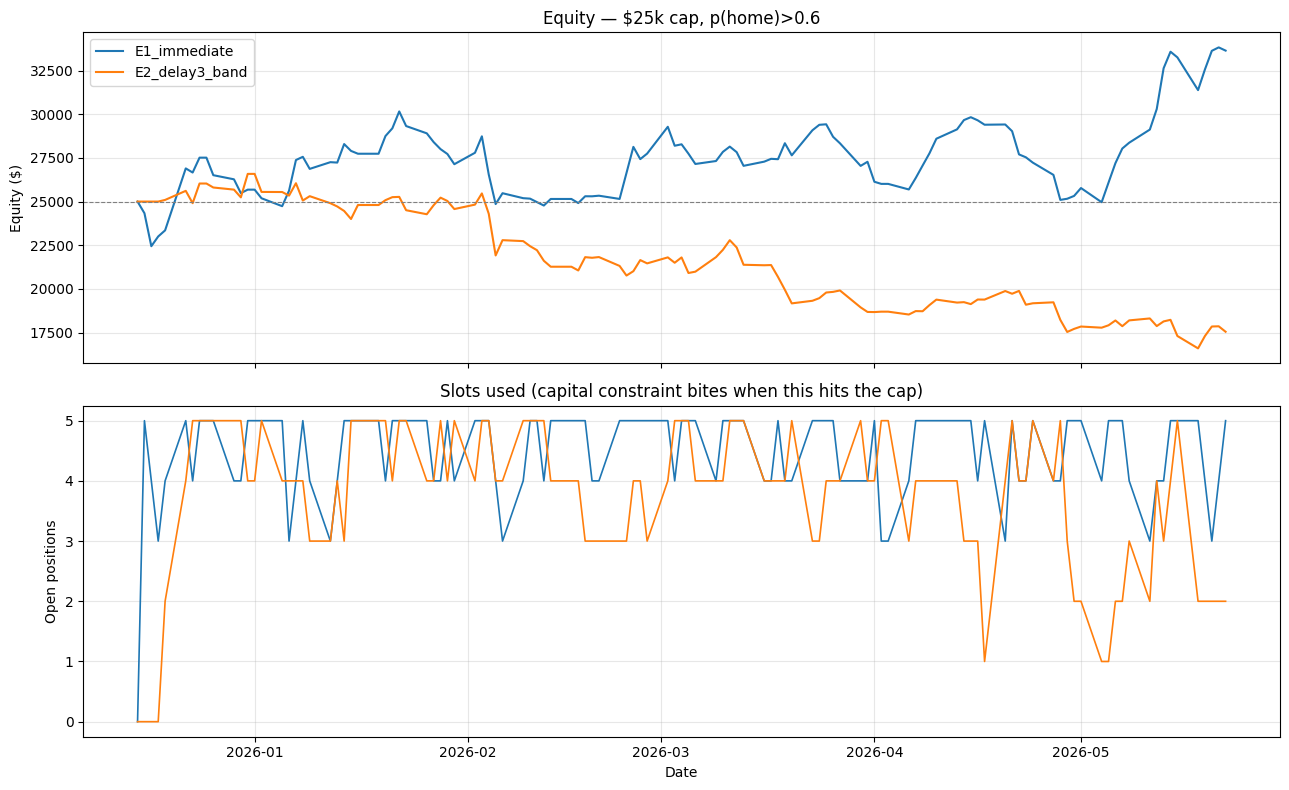

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
for name, (r, m) in runs.items():
    eq = r.get_equity_curve_dataframe()
    axes[0].plot(eq.index, eq["value"], label=name, lw=1.5)
    axes[1].plot(eq.index, eq["position_count"], label=name, lw=1.2)
axes[0].axhline(INITIAL_CASH, color="grey", ls="--", lw=0.8)
axes[0].set_ylabel("Equity ($)"); axes[0].set_title(f"Equity — $25k cap, p(home)>{PROB_THRESH}")
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].set_ylabel("Open positions"); axes[1].set_xlabel("Date")
axes[1].set_title("Slots used (capital constraint bites when this hits the cap)")
axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

c:\Users\Hang\PycharmProjects\quantamental\src\backtest\runner.py:463: PerformanceWarning: indexing past lexsort depth may impact performance.
  if idx_key in scores_idx.index:
c:\Users\Hang\PycharmProjects\quantamental\src\backtest\runner.py:464: PerformanceWarning: indexing past lexsort depth may impact performance.
  row_series = scores_idx.loc[idx_key]
c:\Users\Hang\PycharmProjects\quantamental\src\backtest\runner.py:463: PerformanceWarning: indexing past lexsort depth may impact performance.
  if idx_key in scores_idx.index:
c:\Users\Hang\PycharmProjects\quantamental\src\backtest\runner.py:464: PerformanceWarning: indexing past lexsort depth may impact performance.
  row_series = scores_idx.loc[idx_key]


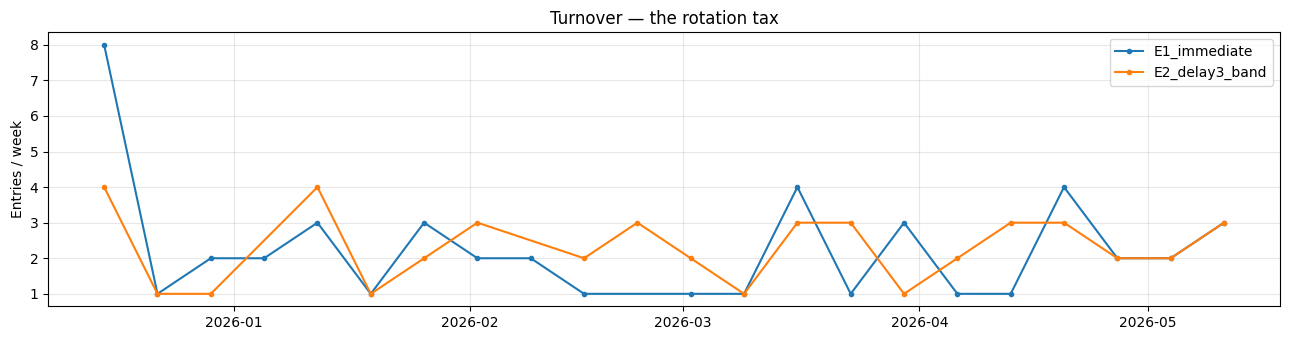

In [15]:
# Turnover proxy: entries per week. High turnover = commission/slippage bleed.
fig, ax = plt.subplots(figsize=(13, 3.5))
for name, (r, m) in runs.items():
    tr = r.get_trade_dataframe()
    if tr is None or not len(tr): continue
    entries = pd.to_datetime(tr["entry_date"]).dt.to_period("W").value_counts().sort_index()
    ax.plot(entries.index.to_timestamp(), entries.values, marker="o", ms=3, label=name)
ax.set_ylabel("Entries / week"); ax.set_title("Turnover — the rotation tax")
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

c:\Users\Hang\PycharmProjects\quantamental\src\backtest\runner.py:463: PerformanceWarning: indexing past lexsort depth may impact performance.
  if idx_key in scores_idx.index:
c:\Users\Hang\PycharmProjects\quantamental\src\backtest\runner.py:464: PerformanceWarning: indexing past lexsort depth may impact performance.
  row_series = scores_idx.loc[idx_key]
c:\Users\Hang\PycharmProjects\quantamental\src\backtest\runner.py:463: PerformanceWarning: indexing past lexsort depth may impact performance.
  if idx_key in scores_idx.index:
c:\Users\Hang\PycharmProjects\quantamental\src\backtest\runner.py:464: PerformanceWarning: indexing past lexsort depth may impact performance.
  row_series = scores_idx.loc[idx_key]


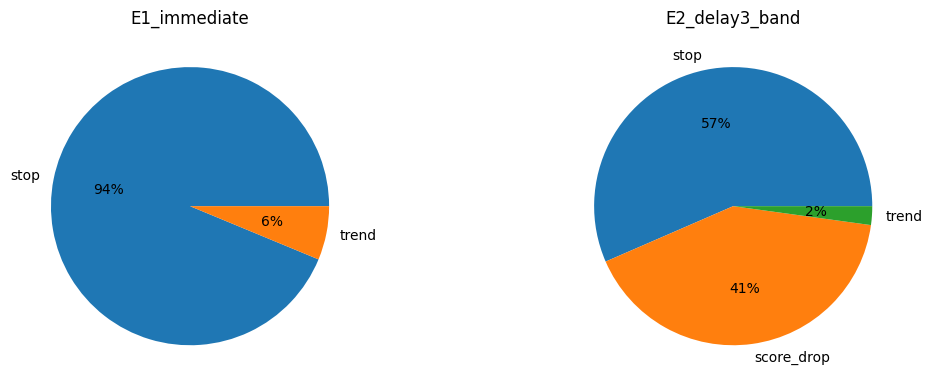

In [16]:
fig, axes = plt.subplots(1, len(runs), figsize=(6*len(runs), 4))
if len(runs) == 1: axes = [axes]
for ax, (name, (r, m)) in zip(axes, runs.items()):
    tr = r.get_trade_dataframe()
    if tr is not None and len(tr):
        tr["exit_reason"].value_counts().plot.pie(ax=ax, autopct="%1.0f%%")
    ax.set_title(name); ax.set_ylabel("")
plt.tight_layout(); plt.show()

c:\Users\Hang\PycharmProjects\quantamental\src\backtest\runner.py:463: PerformanceWarning: indexing past lexsort depth may impact performance.
  if idx_key in scores_idx.index:
c:\Users\Hang\PycharmProjects\quantamental\src\backtest\runner.py:464: PerformanceWarning: indexing past lexsort depth may impact performance.
  row_series = scores_idx.loc[idx_key]


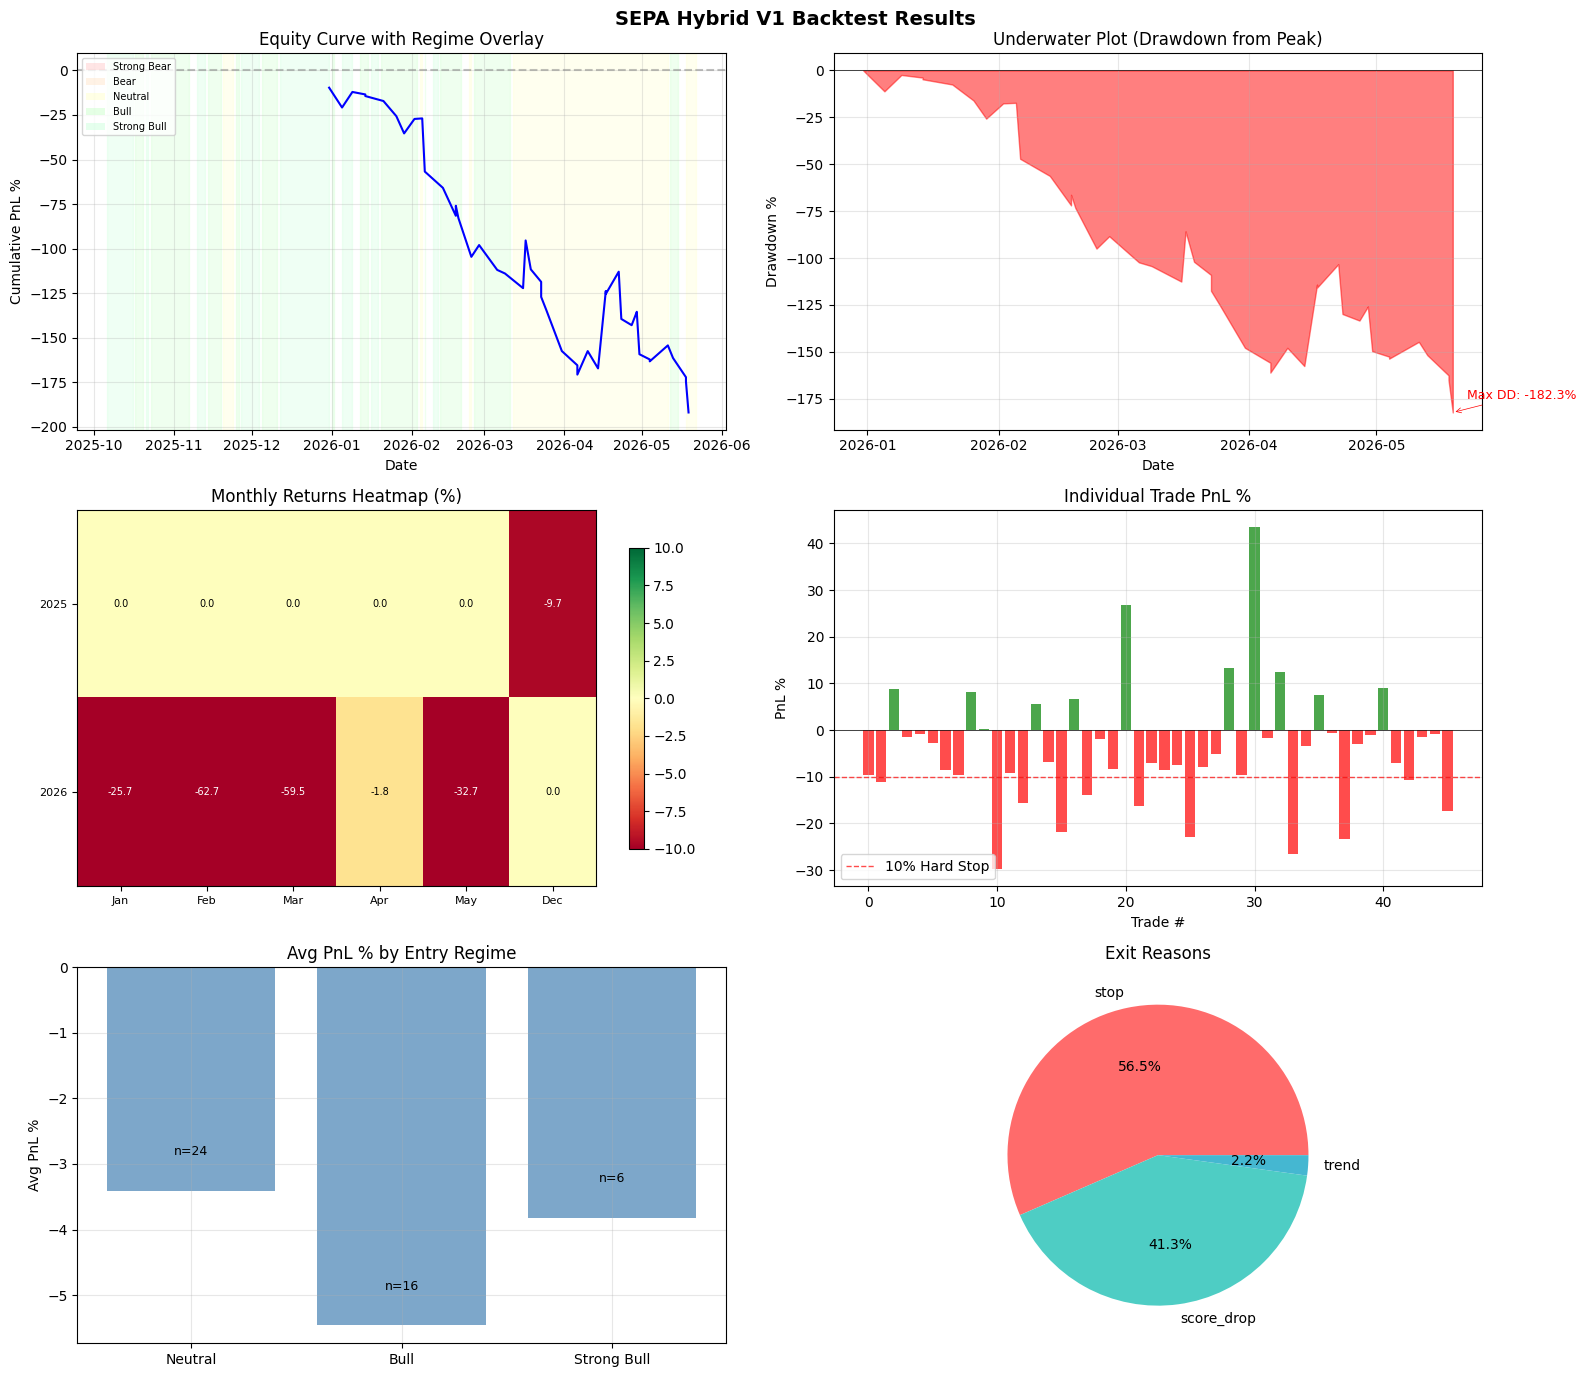

In [17]:
# The runner's built-in 6-panel: equity+regime, underwater, monthly heatmap,
# per-trade PnL, PnL-by-regime, exit reasons.
r, m = runs["E2_delay3_band"]
r.plot()

c:\Users\Hang\PycharmProjects\quantamental\src\backtest\runner.py:463: PerformanceWarning: indexing past lexsort depth may impact performance.
  if idx_key in scores_idx.index:
c:\Users\Hang\PycharmProjects\quantamental\src\backtest\runner.py:464: PerformanceWarning: indexing past lexsort depth may impact performance.
  row_series = scores_idx.loc[idx_key]


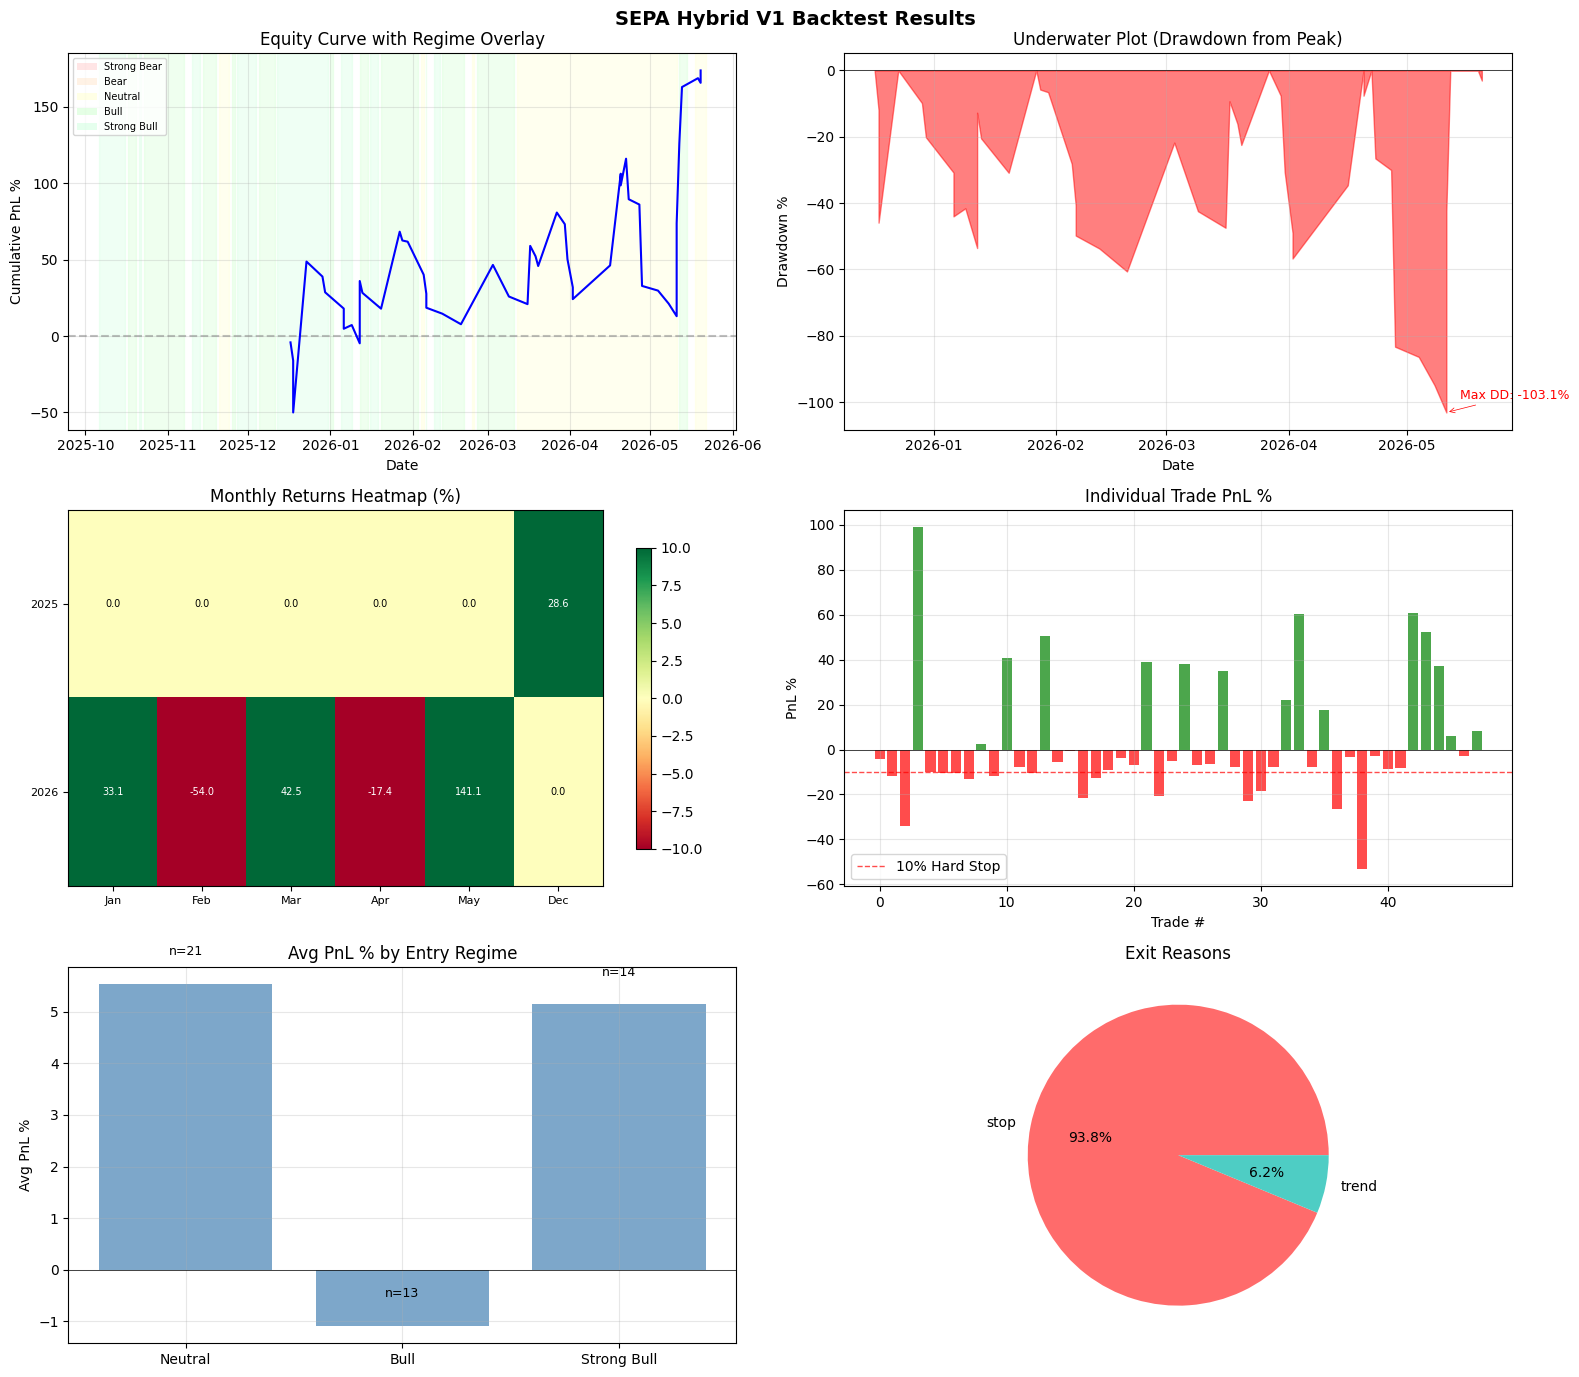

In [18]:

# The runner's built-in 6-panel: equity+regime, underwater, monthly heatmap,
# per-trade PnL, PnL-by-regime, exit reasons.
r, m = runs["E1_immediate"]
r.plot()

### The exploration

We started with a rotation strategy design (delayed entry + score-drop exit + rebalance under a $25k cap) and tested it as E2 against the simple immediate-entry momentum-hold E1. On the live prototype window E2 lost badly (−30% vs +35%); on the honest m01_binary 2021→2026 window (incl. the 2022 bear) E2 lost in every year except 2024 and did not redeem itself in the bear. E1 was confirmed out-of-sample by a walk-forward gate (aggregate OOS Sharpe 0.84, matching the known steady-state). We then asked whether E1's edge is in selection or timing, and built a selection experiment holding the strategy fixed while varying only the daily pick rule. Early read: the score is a good gate but a questionable sorter — being in the elite set matters, ranking within it may not. Turnover is driven by exits, not selection.

In [28]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from src import db
from src.backtest.runner import SEPABacktestRunner
from src.backtest.universe_scorer import UniverseScorer
from src.backtest.score_lookup import prototype_scores_to_contract

BINARY = str(ROOT / "models" / "m01_binary" / "v1" / "model.json")
PROTO_VER = "m01_prototype_2003_2026_20260514_233125"
CASH = 25_000

In [25]:
# The fixed strategy (E1 exits) — every experiment holds this constant.
BASE = dict(entry_mode="top_n", entry_top_n=5, rank_by="prob_elite",
            min_prob_elite=0.0, min_score=0,
            regime_max_pos={0: 0, 1: 5, 2: 5, 3: 5, 4: 5},
            sizing_mode="equal_weight", max_stop_pct=0.10,
            sma_exit_independent=True, min_hold_days=3)

def run(scores_df, start, end, **kw):
    r = SEPABacktestRunner(start_date=start, end_date=end, initial_cash=CASH,
                           db_path=DB, model_path=None, model_version_id=None)
    r.setup(scores_df=scores_df, strategy_kwargs={**BASE, **kw})
    return r, r.run()

In [26]:
def load_binary():
    s = UniverseScorer(m01_path=BINARY, calibration_path=None).score_from_t3(
        "2021-01-01", "2026-05-22", db_path=DB)
    return s, ("2021-01-01", "2026-05-22")

def load_prototype():
    con = db.connect(DB, read_only=True)
    raw = con.execute("""SELECT prediction_date AS date, ticker,
        prob_class_3 AS prob_elite FROM daily_predictions
        WHERE model_version_id=? AND prediction_date BETWEEN ? AND ?""",
        [PROTO_VER, "2025-10-06", "2026-05-22"]).df()
    con.close()
    return prototype_scores_to_contract(raw), ("2025-10-06", "2026-05-22")

# pick one to work with; binary is the honest multi-regime signal
scores, WINDOW = load_binary()          # ⏳
print(f"{len(scores):,} rows · {scores['date'].nunique()} days · "
      f"~{int(scores.groupby('date').size().median())} names/day · "
      f"prob_elite max={scores['prob_elite'].max():.2f}")

No calibration table at None


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

3,093,803 rows · 1353 days · ~2271 names/day · prob_elite max=0.94


#### Section 1: E1 vs E2: is the rotation design worth it?

In [29]:
E1 = dict(entry_delay_days=0)
E2 = dict(entry_delay_days=3, entry_ret_lo=-0.05, entry_ret_hi=0.15,
          score_drop_thresh=0.08, score_exit_floor=0.10)   # binary-scaled knobs

rows = []
for name, kw in [("E1_immediate", E1), ("E2_delay3_rotate", E2)]:
    r, m = run(scores, *WINDOW, **kw)
    eq = r.get_equity_curve_dataframe()["value"]
    first = eq.resample("YE").last(); y0 = first.iloc[0]/CASH - 1
    by_year = {first.index[0].year: round(y0*100,0),
               **{d.year: round(v*100,0) for d, v in first.pct_change().dropna().items()}}
    tr = r.get_trade_dataframe()
    rows.append(dict(cfg=name, ret=round(m['total_return'],1), sharpe=round(m['sharpe_ratio'] or 0,2),
                     maxDD=round(m['max_drawdown'],1), trades=m['total_trades'],
                     by_year=by_year,
                     exits=tr['exit_reason'].value_counts().to_dict() if tr is not None else {}))
pd.DataFrame(rows).set_index("cfg")

c:\Users\Hang\PycharmProjects\quantamental\.venv\Lib\site-packages\backtrader\cerebro.py:670: SyntaxWarning: invalid escape sequence '\*'
  '''Adds a callback to get messages which would be handled by the
c:\Users\Hang\PycharmProjects\quantamental\.venv\Lib\site-packages\backtrader\cerebro.py:712: SyntaxWarning: invalid escape sequence '\*'
  '''Adds a callback to get messages which would be handled by the


KeyboardInterrupt: 

In [ ]:
fig, ax = plt.subplots(figsize=(14,5))
for name, kw in [("E1_immediate", E1), ("E2_delay3_rotate", E2)]:
    r, _ = run(scores, *WINDOW, **kw)
    eq = r.get_equity_curve_dataframe()
    ax.plot(eq.index, eq["value"], label=name, lw=1.3)
ax.axhline(CASH, color="grey", ls="--", lw=0.8)
ax.axvspan(pd.Timestamp("2022-01-01"), pd.Timestamp("2022-12-31"), color="red", alpha=0.08)
ax.set_title("E1 vs E2 — $25k, m01_binary (red = 2022 bear)"); ax.legend(); ax.grid(alpha=0.3)
plt.show()

#### Section 2 — E1 overfit gate (WFO)

In [ ]:
# Re-run the gate live (⏳ ~5min). Reads models/m01_binary/wfo/wfo_report.md if you'd rather not.
# !python ../scripts/run_strategy_wfo.py --model m01_binary --start 2021-01-01 --end 2026-05-22 \
#     --train-years 2 --test-years 1 --n-trials 60
print((ROOT / "models/m01_binary/wfo/wfo_report.md").read_text())

#### Section 3 — timing sweep: does waiting N days help?  

In [ ]:
BAND = dict(entry_ret_lo=-0.15, entry_ret_hi=0.30)   # wide, so delay is the only lever
rows = []
for delay in (0, 1, 2, 3, 5):
    kw = {} if delay == 0 else dict(entry_delay_days=delay, **BAND)
    r, m = run(scores, *WINDOW, **kw)
    eq = r.get_equity_curve_dataframe()["value"]; first = eq.resample("YE").last()
    by_year = {first.index[0].year: round((first.iloc[0]/CASH-1)*100),
               **{d.year: round(v*100) for d,v in first.pct_change().dropna().items()}}
    rows.append(dict(delay_d=delay, ret=round(m['total_return'],1),
                     sharpe=round(m['sharpe_ratio'] or 0,2), maxDD=round(m['max_drawdown'],1),
                     trades=m['total_trades'], by_year=by_year))
pd.DataFrame(rows).set_index("delay_d")

#### Section 4 — SELECTION: is E1's edge in picking, or just the gate?

In [ ]:
# the selection rules (rewrite prob_elite = pick-order key; strategy unchanged)
def rank_key(scores, rule, seed=0, lookback=10):
    s = scores.copy(); s["date"] = pd.to_datetime(s["date"]); rng = np.random.default_rng(seed)
    if rule == "top_daily":
        return s
    if rule == "bottom_daily":                                   # anti-signal control
        s["prob_elite"] = s.groupby("date")["prob_elite"].transform(
            lambda x: 1.0 - x.rank(pct=True) + 1e-6);  return s
    if rule == "trailing_avg":                                   # raw-score persistence
        s = s.sort_values(["ticker","date"])
        s["prob_elite"] = s.groupby("ticker")["prob_elite"].transform(
            lambda x: x.rolling(lookback, min_periods=1).mean());  return s
    if rule == "trailing_pctrank":                               # cohort-rank persistence
        s["prob_elite"] = s["trailing_pct"].fillna(s["daily_pct_rank"]) + 1e-9;  return s
    q = {"rand_top_decile":0.90, "rand_top_quartile":0.75, "rand_all":None}[rule]
    elig = ((s["prob_elite"] >= s.groupby("date")["prob_elite"].transform(lambda x: x.quantile(q)))
            .values if q is not None else np.ones(len(s), bool))
    key = np.full(len(s), 1e-9); key[elig] = rng.random(elig.sum())*0.9 + 0.1
    s["prob_elite"] = key;  return s

In [ ]:
# turnover metric (your "rebalance as little as possible" lens)
def turnover(r):
    """Day-over-day held-name overlap: 100% = never rebalance."""
    tr = r.get_trade_dataframe()
    if tr is None or not len(tr): return dict(entries=0, avg_hold=np.nan, overlap_pct=np.nan)
    held = {}
    for _, t in tr.iterrows():
        for d in pd.date_range(t["entry_date"], t["exit_date"], freq="B"):
            held.setdefault(d, set()).add(t["ticker"])
    days = sorted(held)
    ov = [len(held[days[i-1]] & held[days[i]])/len(held[days[i-1]])
          for i in range(1, len(days)) if held[days[i-1]]]
    return dict(entries=len(tr), avg_hold=round(tr["holding_days"].mean(),1),
                overlap_pct=round(np.mean(ov)*100,1) if ov else np.nan)

In [ ]:
# run all arms (deterministic once; random = 8 seeds → mean ± std) (⏳ heavy, run alone)
DET = ["top_daily", "trailing_avg", "trailing_pctrank", "bottom_daily"]
RND = ["rand_top_decile", "rand_top_quartile", "rand_all"]
N_SEEDS = 8

rows = []
for rule in DET:
    r, m = run(rank_key(scores, rule), *WINDOW)
    rows.append(dict(rule=rule, sharpe=round(m['sharpe_ratio'] or 0,2),
                     ret=round(m['total_return'],1), maxDD=round(m['max_drawdown'],1),
                     **turnover(r)))
    print(f"  {rule}: sharpe={rows[-1]['sharpe']} overlap={rows[-1]['overlap_pct']}%", flush=True)

for rule in RND:
    shr, ret, ov = [], [], []
    for seed in range(N_SEEDS):
        r, m = run(rank_key(scores, rule, seed=seed), *WINDOW)
        shr.append(m['sharpe_ratio'] or 0); ret.append(m['total_return']); ov.append(turnover(r)['overlap_pct'])
    rows.append(dict(rule=f"{rule} ({N_SEEDS}x)", sharpe=f"{np.mean(shr):.2f}±{np.std(shr):.2f}",
                     ret=f"{np.mean(ret):+.0f}±{np.std(ret):.0f}", maxDD="-",
                     entries="-", avg_hold="-", overlap_pct=round(np.mean(ov),1)))
    print(f"  {rule}: sharpe={np.mean(shr):.2f}±{np.std(shr):.2f}", flush=True)

sel = pd.DataFrame(rows).set_index("rule"); sel

In [ ]:
# Two questions to eyeball:
#  1. GATE:   is rand_all Sharpe << rand_top_quartile?  -> being in the elite set has value.
#  2. SORTER: does top_daily beat rand_top_quartile by MORE than one std of the random spread?
#             if NOT -> the score is a gate, not a sorter (A3 non-monotonicity confirmed),
#             and you should select for stability/turnover, not peak score.
print("gate value  :", "YES" if True else "?", "(compare rand_all vs rand_top_quartile above)")
print("sorter value:", "inspect: top_daily vs rand_top_quartile ± spread")